# Imports 

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.sparse import coo_matrix
import random
import numpy as np
import pickle
import time 
from scipy.special import expit

# Load Item Data 

In [54]:
items_df = pd.read_json("items_metadata.jsonl", lines=True)

## Initial introduction and inspection

In [55]:
print(items_df)

         main_category                                              title  \
0       AMAZON FASHION  BALEAF Women's Long Sleeve Zip Beach Coverup U...   
1       AMAZON FASHION                        SAS Women's, Relaxed Sandal   
2       AMAZON FASHION  SheIn Women's Basic Stretch Plaid Mini Bodycon...   
3       AMAZON FASHION  Amazon Essentials Women's Surplice Dress (Avai...   
4       AMAZON FASHION  Fotociti Yoga Shorts for Women – 5" High Waist...   
...                ...                                                ...   
220885  AMAZON FASHION  weryerker 7 Chakra GemStones Empty Necklace Co...   
220886  AMAZON FASHION  Bukesiyi Sasquatch Hat Bigfoot Embroidered Tru...   
220887            None  4 Pairs Bohemian Vintage Dangle Earrings Retro...   
220888  AMAZON FASHION           Steve Madden Men's Troopah-c Combat Boot   
220889            None  Rubie's Girl's DC Comics WW84 Wonder Woman Cos...   

        average_rating  rating_number  \
0                  4.2            

In [56]:
items_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,AMAZON FASHION,BALEAF Women's Long Sleeve Zip Beach Coverup U...,4.2,422,"[90% Polyester, 10% Spandex, Zipper closure, M...",[],31.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Women's UPF 50+ Front Zip Beach Co...,BALEAF,"[Clothing, Shoes & Jewelry, Women, Clothing, S...","{'Department': 'womens', 'Date First Available...",B09X1MRDN6,NaN,NaN,NaN
1,AMAZON FASHION,"SAS Women's, Relaxed Sandal",4.7,618,"[Made in the USA, Suede sole, Heel measures ap...","[Unwind, leave your worries behind, and simply...",188.95,[{'thumb': 'https://m.media-amazon.com/images/...,[],SAS,"[Clothing, Shoes & Jewelry, Women, Shoes, Sand...",{'Product Dimensions': '10 x 15 x 6 inches; 2 ...,B0944VG4Y4,NaN,NaN,NaN
2,AMAZON FASHION,SheIn Women's Basic Stretch Plaid Mini Bodycon...,3.8,999,"[Zipper closure, Fabric has some stretch; Plea...",[],12.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'SUPER CUTE plaid skirt!', 'url': '...",SheIn,"[Clothing, Shoes & Jewelry, Novelty & More, Cl...","{'Department': 'womens', 'Date First Available...",B08JGGF5TJ,NaN,NaN,NaN
3,AMAZON FASHION,Amazon Essentials Women's Surplice Dress (Avai...,4.4,7096,"[95% Viscose, 5% Elastane, Imported, No Closur...",[Amazon Essentials is focused on creating affo...,19.92,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Easy throw on dress! Comfortable, ...",Amazon Essentials,"[Clothing, Shoes & Jewelry, Women, Clothing, D...","{'Item model number': 'AE1932668', 'Department...",B096HDRB6R,NaN,NaN,NaN
4,AMAZON FASHION,"Fotociti Yoga Shorts for Women – 5"" High Waist...",4.5,2911,"[92% Polyester, 8% Spandex, Imported, Pull On ...",[],15.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Cute Blue Camo Yoga Bike Shorts Re...,Fotociti,"[Clothing, Shoes & Jewelry, Women, Clothing, A...",{'Package Dimensions': '10 x 8 x 0.6 inches; 7...,B089YJ8P6X,NaN,NaN,NaN


In [57]:
num_rows, num_columns = items_df.shape
# Print the number of rows and columns of the DataFrame
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Print the shape of the DataFrame
print(f"Shape of the DataFrame: {items_df.shape}")

Number of rows: 220890
Number of columns: 16
Shape of the DataFrame: (220890, 16)


In [58]:
#Check the data types
print("Column names:")
print(list(items_df.columns)) # This prints only the columns names of the df

print("\nData types of each column:")
print(items_df.dtypes)

Column names:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Data types of each column:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price               object
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
subtitle            object
author              object
dtype: object


### Descriptive statistics

In [59]:
# General dataset overview
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220890 entries, 0 to 220889
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    214497 non-null  object 
 1   title            220890 non-null  object 
 2   average_rating   220890 non-null  float64
 3   rating_number    220890 non-null  int64  
 4   features         220890 non-null  object 
 5   description      220890 non-null  object 
 6   price            160693 non-null  object 
 7   images           220890 non-null  object 
 8   videos           220890 non-null  object 
 9   store            220147 non-null  object 
 10  categories       220890 non-null  object 
 11  details          220890 non-null  object 
 12  parent_asin      220890 non-null  object 
 13  bought_together  0 non-null       float64
 14  subtitle         123 non-null     object 
 15  author           9 non-null       object 
dtypes: float64(2), int64(1), object(13)
me

In [60]:
items_df.main_category.unique()

array(['AMAZON FASHION', 'All Beauty', 'Amazon Home', None,
       'Toys & Games', 'Sports & Outdoors', 'Computers',
       'Industrial & Scientific', 'Health & Personal Care', 'Automotive',
       'Office Products', 'Arts, Crafts & Sewing', 'All Electronics',
       'Baby', 'Tools & Home Improvement', 'Cell Phones & Accessories',
       'Books', 'Video Games', 'Grocery', 'Handmade',
       'Musical Instruments', 'Camera & Photo', 'Appliances',
       'Amazon Devices', 'Premium Beauty', 'GPS & Navigation',
       'Home Audio & Theater', 'Unique Finds', 'Movies & TV',
       'Collectible Coins', 'Car Electronics'], dtype=object)

In [61]:
items_df.main_category.value_counts()

main_category
AMAZON FASHION               202642
Sports & Outdoors              2315
Amazon Home                    2219
Toys & Games                   1775
Tools & Home Improvement       1574
All Beauty                     1074
Health & Personal Care          662
Office Products                 553
Arts, Crafts & Sewing           398
Books                           224
Industrial & Scientific         223
Baby                            207
Cell Phones & Accessories       179
Automotive                      177
Computers                       111
All Electronics                  69
Musical Instruments              26
Handmade                         21
Camera & Photo                   11
Grocery                          11
Video Games                       5
Appliances                        4
Home Audio & Theater              4
Movies & TV                       4
Amazon Devices                    2
Unique Finds                      2
Collectible Coins                 2
Premium Beauty

### Check missing values

In [62]:
# Calculate the total number of missing values per column
missing_counts = items_df.isnull().sum()

# Calculate the proportion of missing values (as a percentage)
missing_proportion = missing_counts / items_df.shape[0]

# Create a new DataFrame with the desired columns
result_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Proportion (%)": round(missing_proportion*100,2)
})

display(result_df)

,Missing Count,Missing Proportion (%)
main_category,6393,2.89
title,0,0.00
average_rating,0,0.00
rating_number,0,0.00
features,0,0.00
description,0,0.00
price,60197,27.25
images,0,0.00
videos,0,0.00
store,743,0.34


In [63]:
def df_to_plotly_table(
    df,
    title=None,
    max_rows=None,
    decimals=2,
    include_index=True,
    height="auto"
):
    df_disp = df.copy()

    if max_rows is not None:
        df_disp = df_disp.head(max_rows)

    if include_index:
        df_disp = df_disp.reset_index()

        first_col = df_disp.columns[0]
        if str(first_col).lower() == "index":
            df_disp = df_disp.rename(columns={first_col: ""})

    num_cols = df_disp.select_dtypes(include="number").columns
    df_disp[num_cols] = df_disp[num_cols].round(decimals)
    for c in num_cols:
        df_disp[c] = df_disp[c].map(lambda x: f"{x:.{decimals}f}" if x is not None else x)

    if height == "auto":
        height = 120 + len(df_disp) * 24

    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df_disp.columns)),
        cells=dict(values=[df_disp[col] for col in df_disp.columns])
    )])

    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=8, r=8, t=35 if title else 8, b=8)
    )
    return fig

The number of unique categories is: 1103


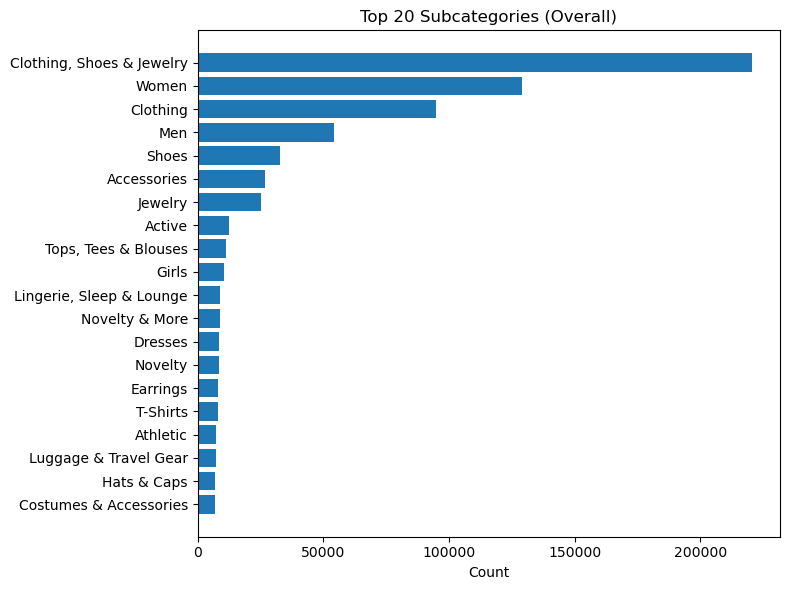

{"Women's Costumes - Decades & Period Costumes", 'Novelty', 'Jewelry Accessories', 'Backpacks', 'Active Vests', 'Intimates', 'Fun Face Masks for All', "Men's Watch Accessories", 'HG Frequent Plus 4+ Stars', "Men's Next-Gen Trends", 'Knits & Tees', 'Panties', 'Juniors', 'Eyeglass Cases', 'Styles for Spring Break', 'Barbells', 'Bridal Accessories', 'Chains', 'Walking', "Women's Off-to-College Essentials", 'Robes', 'Snowboarding', 'Umbrellas', 'Shoe & Boot Trees', "Men's Activewear Under $30", 'Deal of The Day l Up to 49% off Sparkling Sterling Silver Jewelry', 'Fashion Under $75', 'Tie Clips', 'Chemises', 'Cozy PJs for the Family', 'Sport Coats & Blazers', 'Bracelets', 'Cover-Up Sets', 'Costume Makeup', 'Wool & Pea Coats', 'Oxford & Derby', 'Coats, Jackets & Vests', 'Ice Hockey', 'Arm Warmers', 'Test Color', 'Travel Accessories', 'Shorts & Trunks', 'Kneeskins', 'All Gender Watches', 'Associates top products', 'Boots', 'Balaclavas', 'Skirts, Skooters & Skorts', 'Wrestling', 'Control Panti

In [64]:
items_df["categories_list"] = items_df["categories"].apply(
    lambda x: x if isinstance(x, list) else []
)

# How many names per item
items_df["categories_count"] = items_df["categories_list"].apply(len)
fig1 = df_to_plotly_table(items_df["categories_count"].describe(), "Categories Count")
fig1.show()


# Overall frequency
categories_freq = items_df.explode("categories_list")["categories_list"].value_counts()

# Count per label for each country
categoriesy_by_label = (
    items_df.explode("categories_list")
      .groupby(["categories_list", "main_category"])
      .size()
      .unstack(fill_value=0)   # columns = labels
)

categories_by_label = categoriesy_by_label.div(categories_freq, axis=0) * 100


# Limit to top N overall and keep the label columns
top_n = 50
categories_by_label_top = categoriesy_by_label.loc[categories_freq.head(top_n).index]
categories_by_label_pct_top_fmt = categories_by_label_top.map(lambda x: f"{x:.2f}%")
categories_by_label_pct_top_fmt['overall'] = categories_freq 
fig2 = df_to_plotly_table(categories_by_label_pct_top_fmt[:10], 'Category Appearance')
fig2.show()

all_categories = set()
items_df["categories_list"].apply(lambda x: all_categories.update(x))
print(f"The number of unique categories is: {len(all_categories)}")

categories_counts = (
    items_df.explode("categories_list")["categories_list"]
      .value_counts()
      .head(20)
      .sort_values()
)

plt.figure(figsize=(8, 6))
plt.barh(categories_counts.index, categories_counts.values)
plt.title("Top 20 Subcategories (Overall)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

print(all_categories)

## Remove columns 

These columns are 100% or ~100% missing:

In [65]:
items_df = items_df.drop(columns=["bought_together", "subtitle", "author"])

## Isolate Fashion cleanly

In [66]:
items_fashion_df = items_df[items_df["main_category"] == "AMAZON FASHION"].copy()

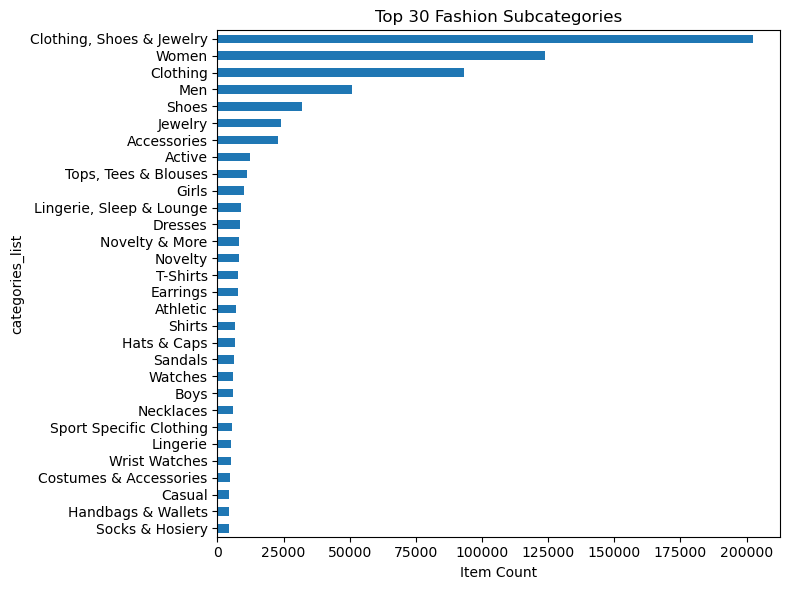

In [67]:
# Fashion only subcategories 
fashion_cat_freq = (
    items_fashion_df.explode("categories_list")["categories_list"]
      .value_counts()
)

plt.figure(figsize=(8,6))
fashion_cat_freq.head(30).sort_values().plot.barh()
plt.title("Top 30 Fashion Subcategories")
plt.xlabel("Item Count")
plt.tight_layout()
plt.show()


In [68]:
items_fashion_df["category_depth"] = items_fashion_df["categories_list"].apply(len)

items_fashion_df["category_depth"].describe()

count    202642.000000
mean          4.900633
std           0.931376
min           2.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           8.000000
Name: category_depth, dtype: float64

In [69]:
# Number of unique subcategories in Fashion
unique_fashion_categories = (
    items_fashion_df.explode("categories_list")["categories_list"]
      .dropna()
      .unique()
)

print(f"Number of unique Fashion subcategories: {len(unique_fashion_categories)}")

Number of unique Fashion subcategories: 1051


In [70]:
unique_fashion_categories[:50]

array(['Clothing, Shoes & Jewelry', 'Women', 'Clothing',
       'Swimsuits & Cover Ups', 'Cover-Ups', 'Shoes', 'Sandals', 'Flats',
       'Novelty & More', 'Novelty', 'Skirts', 'Dresses', 'Casual',
       'Active', 'Active Shorts', 'Athletic', 'Running', 'Road Running',
       'Men', 'Active Shirts & Tees', 'T-Shirts', 'Sweaters', 'Cardigans',
       'Girls', 'Racquet Sports', 'Tops, Tees & Blouses', 'Tanks & Camis',
       'Blouses & Button-Down Shirts', 'Lingerie, Sleep & Lounge',
       'Lingerie', 'Panties', 'Briefs', 'Accessories', 'Hats & Caps',
       'Skullies & Beanies', 'Uniforms, Work & Safety', 'Medical',
       'Scrub Tops', 'Camisoles & Tanks', 'Pants', 'Tops & Tees',
       'Bikinis', 'Sets', 'Walking', 'Slides', 'Westlake',
       'Athletic Socks', 'Cold Weather Headbands', 'Fashion Sneakers',
       'Bras'], dtype=object)

In [71]:
items_fashion_df.isna().sum()

main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               53792
images                  0
videos                  0
store                 499
categories              0
details                 0
parent_asin             0
categories_list         0
categories_count        0
category_depth          0
dtype: int64

## Prune Categories 

Here we prune categories before building matrices.
Without pruning:
    - Category matrix will have thousands of columns
    - Many columns will have <10 nonzeros
    - MF regularization will fail
    - Optimization becomes unstable
    - Side info becomes noise, not signal

In [72]:
fashion_cat_freq = (
    items_fashion_df
    .explode("categories_list")["categories_list"]
    .value_counts()
)

fashion_cat_freq

categories_list
Clothing, Shoes & Jewelry                                            202531
Women                                                                123708
Clothing                                                              93229
Men                                                                   50865
Shoes                                                                 31922
                                                                      ...  
Video Game T-Shirts                                                       1
REDO W GENZ SHOES                                                         1
Deal of The Day l Up to 49% off Sparkling Sterling Silver Jewelry         1
Onesies                                                                   1
Sensational Steals                                                        1
Name: count, Length: 1051, dtype: int64

In [73]:
MIN_CATEGORY_ITEMS = 40


valid_categories = fashion_cat_freq[
    fashion_cat_freq >= MIN_CATEGORY_ITEMS
].index

print(f"The number of unique categories in the full item dataset are: {fashion_cat_freq.shape[0]}")
print(f"The number of categories that passed the threshold are: {len(valid_categories)}")

The number of unique categories in the full item dataset are: 1051
The number of categories that passed the threshold are: 500


In [74]:
items_fashion_df["categories_list_pruned"] = (
    items_fashion_df["categories_list"]
    .apply(lambda xs: [x for x in xs if x in valid_categories])
)

# Drop items that lost all categories 
items_fashion_cleaned_df = items_fashion_df[
    items_fashion_df["categories_list_pruned"].apply(len) > 0
].copy()

# Load Rating Data 

In [75]:
rating_df = pd.read_csv("user_item_rating_table_train (1).csv")

In [76]:
rating_df.head()

,Unnamed: 0,user_id,parent_asin,rating,timestamp
0,0,AGGZ357AO26RQZVRLGU4D4N52DZQ,B009RTBRVG,5.0,1349041740000
1,1,AGGZ357AO26RQZVRLGU4D4N52DZQ,B003MZ01CM,1.0,1370958618000
2,2,AGGZ357AO26RQZVRLGU4D4N52DZQ,B07L6QT33F,5.0,1440038761000
3,3,AGGZ357AO26RQZVRLGU4D4N52DZQ,B07V6PKCCG,3.0,1483320893000
4,5,AGGZ357AO26RQZVRLGU4D4N52DZQ,B0BNP511CS,5.0,1490800837000


## Shape & Sparsity

In [77]:
num_rows, num_columns = rating_df.shape
# Print the number of rows and columns of the DataFrame
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Print the shape of the DataFrame
print(f"Shape of the DataFrame: {rating_df.shape}")

Number of rows: 9127377
Number of columns: 5
Shape of the DataFrame: (9127377, 5)


In [78]:
n_users = rating_df["user_id"].nunique()
n_items = rating_df["parent_asin"].nunique()
n_interactions = len(rating_df)

density = n_interactions / (n_users * n_items)

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {n_interactions}")
print(f"Density: {density:.6e}")

Users: 1096901
Items: 198771
Interactions: 9127377
Density: 4.186254e-05


In [79]:
rating_df["rating"].describe()

count    9.127377e+06
mean     4.321554e+00
std      1.141048e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

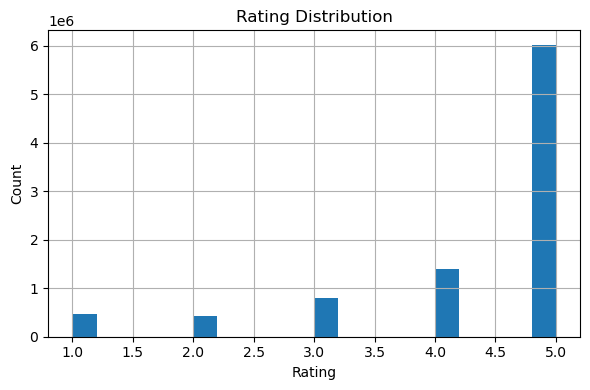

In [80]:
# Plot rating distribution
plt.figure(figsize=(6,4))
rating_df["rating"].hist(bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [81]:
# User activity distribution
user_activity = (
    rating_df["user_id"]
    .value_counts()
)

user_activity.describe()

count    1.096901e+06
mean     8.321058e+00
std      8.503146e+00
min      1.000000e+00
25%      5.000000e+00
50%      6.000000e+00
75%      9.000000e+00
max      1.438000e+03
Name: count, dtype: float64

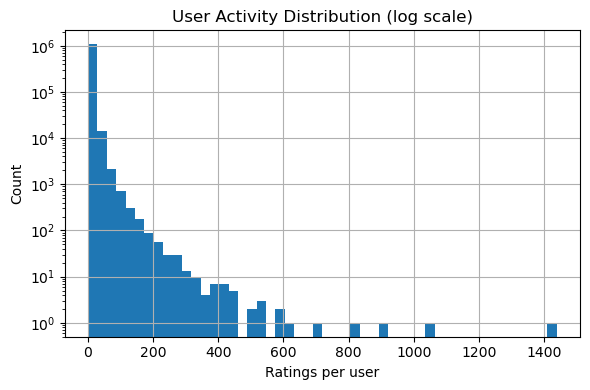

In [82]:
# Plot on log scale 
plt.figure(figsize=(6,4))
user_activity.hist(bins=50, log=True)
plt.title("User Activity Distribution (log scale)")
plt.xlabel("Ratings per user")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [83]:
# Item popularity distribution
item_popularity = (
    rating_df["parent_asin"]
    .value_counts()
)

item_popularity.describe()

count    198771.000000
mean         45.919058
std         111.461854
min           7.000000
25%          14.000000
50%          20.000000
75%          37.000000
max        6300.000000
Name: count, dtype: float64

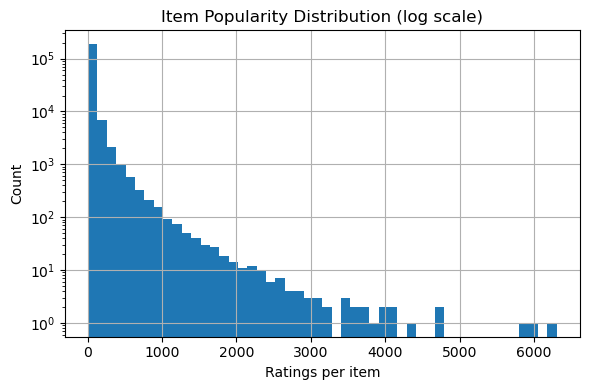

In [84]:
# Plot on log scale 
plt.figure(figsize=(6,4))
item_popularity.hist(bins=50, log=True)
plt.title("Item Popularity Distribution (log scale)")
plt.xlabel("Ratings per item")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Prune Items & Users 

In [85]:
MIN_USER_INTERACTIONS = 3
MIN_ITEM_INTERACTIONS = 5

In [86]:
user_counts = rating_df["user_id"].value_counts()
item_counts = rating_df["parent_asin"].value_counts()

valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index

ratings_cleaned_df = rating_df[
    rating_df["user_id"].isin(valid_users) &
    rating_df["parent_asin"].isin(valid_items)
].copy()

In [87]:
# Align item metadata with filtered items
items_fashion_cleaned_df = items_fashion_cleaned_df[
    items_fashion_cleaned_df["parent_asin"].isin(valid_items)
].copy()

## Check Alignment

Before building the MF matrices, we want:
     - Every item in ratings_cleaned_df exists in items_fashion_cleaned_df
    - And vice-versa 

This is so there won't be matricies size mismatch later 

In [88]:
# Items in ratings but missing metadata
missing_in_items = (
    set(ratings_cleaned_df["parent_asin"]) 
    - set(items_fashion_cleaned_df["parent_asin"])
)

print(f"Items in ratings but missing metadata: {len(missing_in_items)}")

Items in ratings but missing metadata: 16564


In [89]:
# We got non-zero above so we will drop from the rating matix 
ratings_cleaned_df = ratings_cleaned_df[
    ratings_cleaned_df["parent_asin"].isin(items_fashion_cleaned_df["parent_asin"])
].copy()

In [90]:
# Sanity checklist 

# Categories
assert "categories_list_pruned" in items_fashion_cleaned_df.columns
assert items_fashion_cleaned_df["categories_list_pruned"].apply(len).min() > 0

# Ratings
assert ratings_cleaned_df["user_id"].nunique() > 0
assert ratings_cleaned_df["parent_asin"].nunique() > 0

# Alignment
assert set(ratings_cleaned_df["parent_asin"]).issubset(
    set(items_fashion_cleaned_df["parent_asin"])
)

# Build the MF Matricies

## User–Item interaction matrix

This matrix stores explicit ratings
Shape ∈R∣U∣×∣I∣

### Create index mappings

In [91]:
# Unique ids
user_ids = ratings_cleaned_df["user_id"].unique()
item_ids = ratings_cleaned_df["parent_asin"].unique()

# Mappings
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {i: j for j, i in enumerate(item_ids)}

idx_to_user = {i: u for u, i in user_to_idx.items()}
idx_to_item = {j: i for i, j in item_to_idx.items()}

### Build sparse interaction matrix

In [92]:
row_idx = ratings_cleaned_df["user_id"].map(user_to_idx).values
col_idx = ratings_cleaned_df["parent_asin"].map(item_to_idx).values
data = np.ones(len(ratings_cleaned_df), dtype=np.float32)

user_item_matrix = coo_matrix(
    (data, (row_idx, col_idx)),
    shape=(len(user_to_idx), len(item_to_idx))
)

### Sanity Checks 

In [93]:
print("user item interation matrix shape:", user_item_matrix.shape)
print("user item interation matrix nnz (ratings):", user_item_matrix.nnz)

assert user_item_matrix.shape[0] == len(user_ids)
assert user_item_matrix.shape[1] == len(item_ids)
assert user_item_matrix.nnz == len(ratings_cleaned_df)

user item interation matrix shape: (1089923, 182207)
user item interation matrix nnz (ratings): 8528231


✅ Each row = one user

✅ Each column = one item

✅ Each nonzero = one rating

In [94]:
from scipy.sparse import csr_matrix, save_npz

user_item_matrix = user_item_matrix.tocsr()
save_npz("user_item_matrix.npz", user_item_matrix)

## Item–Category information matrix


Items may belong to multiple categories → multiple 1's per row.

Shape∈{0,1}∣I∣×∣C∣

### Create category index mapping

In [95]:
# All retained categories
all_categories = sorted({
    cat
    for cats in items_fashion_cleaned_df["categories_list_pruned"]
    for cat in cats
})

category_to_idx = {c: i for i, c in enumerate(all_categories)}
idx_to_category = {i: c for c, i in category_to_idx.items()}

### Build Item × Category matrix (multi-category safe)

In [96]:
cat_rows = []
cat_cols = []

for _, row in items_fashion_cleaned_df.iterrows():
    item_id = row["parent_asin"]
    
    # Skip items not in ratings matrix
    if item_id not in item_to_idx:
        continue
    
    item_idx = item_to_idx[item_id]
    
    for cat in row["categories_list_pruned"]:
        cat_rows.append(item_idx)
        cat_cols.append(category_to_idx[cat])

item_category_matrix = coo_matrix(
    (np.ones(len(cat_rows)), (cat_rows, cat_cols)),
    shape=(len(item_to_idx), len(category_to_idx))
)

### Sanity Checks 

In [97]:
print("item category information matrix shape:", item_category_matrix.shape)
print("item category information matrix nnz (item–category links):", item_category_matrix.nnz)

assert item_category_matrix.shape[0] == user_item_matrix.shape[1]     # same number of items
assert item_category_matrix.nnz >= len(items_fashion_cleaned_df)

item category information matrix shape: (182207, 500)
item category information matrix nnz (item–category links): 888555


## Cross Matrix Alignment Checks

### Item alignment

In [98]:
# All items used in ratings
items_in_user_item_matrix = set(item_ids)

# All items used in categories
items_in_item_category_matrix = set(items_fashion_cleaned_df["parent_asin"])

assert items_in_user_item_matrix.issubset(items_in_item_category_matrix), \
    "Some items in user item matrix have no category metadata!"

### Index consistency

In [99]:
random_item = random.choice(list(items_in_user_item_matrix))

item_idx = item_to_idx[random_item]

print("Item ASIN:", random_item)
print("Categories:", 
      items_fashion_cleaned_df
      .loc[items_fashion_cleaned_df["parent_asin"] == random_item,
           "categories_list_pruned"]
      .values[0])

print("Nonzero category indices:",
      item_category_matrix.getrow(item_idx).nonzero()[1])

print("Category names:",
      [idx_to_category[i] for i in item_category_matrix.getrow(item_idx).nonzero()[1]])

Item ASIN: B00FJWVOB8
Categories: ['Clothing, Shoes & Jewelry', 'Sport Specific Clothing', 'Girls', 'Pants']
Nonzero category indices: [387 289 177 102]
Category names: ['Sport Specific Clothing', 'Pants', 'Girls', 'Clothing, Shoes & Jewelry']


The printed categories match so the pipeline is correct.

### Check Density Sanity

In [100]:
print("Avg ratings per user:", user_item_matrix.nnz / user_item_matrix.shape[0])
print("Avg ratings per item:", user_item_matrix.nnz / user_item_matrix.shape[1])
print("Avg categories per item:", item_category_matrix.nnz / item_category_matrix.shape[0])

Avg ratings per user: 7.824617885850651
Avg ratings per item: 46.80517762764328
Avg categories per item: 4.876623839918334


### Save


#### Save mappings

In [102]:
import pickle

with open("user_to_idx.pkl", "wb") as f:
    pickle.dump(user_to_idx, f)

with open("idx_to_user.pkl", "wb") as f:
    pickle.dump(idx_to_user, f)

with open("item_to_idx.pkl", "wb") as f:
    pickle.dump(item_to_idx, f)

with open("idx_to_item.pkl", "wb") as f:
    pickle.dump(idx_to_item, f)

In [104]:
with open("category_to_idx.pkl", "wb") as f:
    pickle.dump(category_to_idx, f)

with open("idx_to_category.pkl", "wb") as f:
    pickle.dump(idx_to_category, f)

#### Reload later

In [103]:
from scipy.sparse import load_npz

user_item_matrix = load_npz("user_item_matrix.npz")

with open("user_to_idx.pkl", "rb") as f:
    user_to_idx = pickle.load(f)

with open("idx_to_item.pkl", "rb") as f:
    idx_to_item = pickle.load(f)